In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

np.set_printoptions(precision=32)

In [40]:
data = np.genfromtxt(r"./img_pt0.txt",delimiter=",",dtype = np.float64)
data_src = np.genfromtxt(r"./src_pt0.txt",delimiter=",")
Crit = np.genfromtxt(r"./critcaus.txt",delimiter=",")
NPOINTS = len(data)//5

# each line in data is a image point
# data.T[0] : "i", means which source point it belongs to
# data.T[1] : "j": from [0,1,2,3,4] distinguishes the 5 image points
# data.T[2] : x coordinate
# data.T[3] : y coordinate
# data.T[4] : 1 physcial, 0 ghost
# data.T[5] : parity, 1 negative, 0 positive
# data.T[6] : piece area formed by this image point and the next image point
# data.T[7] : next image point's "i"
# data.T[8] : next image point's "j"
# data.T[9] : error of data.T[6]
# others are shown in init.cpp Twinkle::write()
# demo txt file might be different in the following columns

# each line in data_src is a source point
# data_src.T[0] : x coordinate
# data_src.T[1] : y coordinate
# data_src.T[2] : next source point's "i"
# data_src.T[3] : Q, theta / 2pi
# data_src.T[4] : previous source point's "i"
# data_src.T[5] : 1 if solved succeed
# data_src.T[6] : number of physical images
# others are shown in init.cpp Twinkle::write()
# demo txt file might be different in the following columns

# each line in Crit represents a point on critical curve and caustic
# Crit.T[0] : index of psi
# Crit.T[1] : psi
# Crit.T[2] : critcal curve x coordinate
# Crit.T[3] : critcal curve y coordinate
# Crit.T[4] : caustic x coordinate
# Crit.T[5] : caustic y coordinate


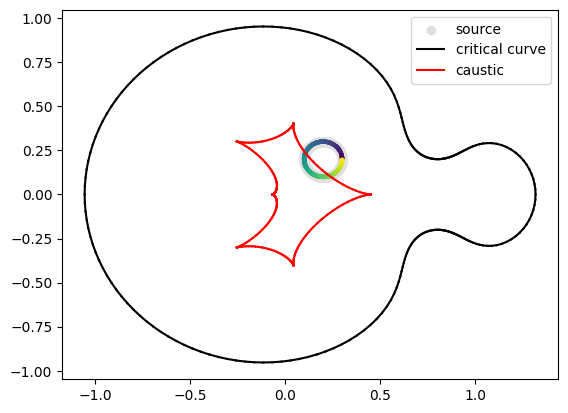

In [41]:
xs = data_src.T[0]
ys = data_src.T[1]
plt.scatter(xs,ys,c="#E0E0E0",label="source")
plt.scatter(xs,ys,c=data_src.T[3],s=5)

NCRIT = len(Crit)//4

for i in range(len(Crit)):
    xs = np.array([Crit.T[0][i],Crit.T[0][int((i+1)%NCRIT + Crit.T[4][i]*NCRIT)]])
    ys = np.array([Crit.T[1][i],Crit.T[1][int((i+1)%NCRIT + Crit.T[4][i]*NCRIT)]])
    if i!=0:
        plt.plot(xs,ys,c="black")
    else:
        plt.plot(xs,ys,c="black",label="critical curve")

for i in range(len(Crit)):
    xs = np.array([Crit.T[2][i],Crit.T[2][int((i+1)%NCRIT + Crit.T[4][i]*NCRIT)]])
    ys = np.array([Crit.T[3][i],Crit.T[3][int((i+1)%NCRIT + Crit.T[4][i]*NCRIT)]])
    if i!=0:
        plt.plot(xs,ys,c="red")
    else:
        plt.plot(xs,ys,c="red",label="caustic")
plt.legend()

Text(0.5, 1.0, 'Image Plane')

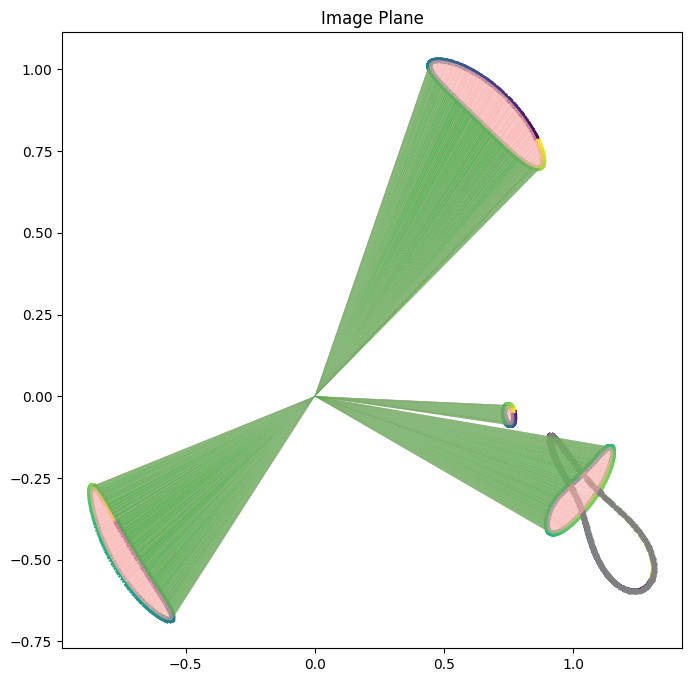

In [42]:
fig = plt.figure(figsize=[8,8])

# 深色是虚像 用的是viridis配色
# plt.scatter(data.T[2],data.T[3],s=0.1)
ax = fig.add_subplot(111)

ax.scatter(data.T[2][data.T[5]==0],data.T[3][data.T[5]==0],c=data_src.T[3][np.array(data.T[0][data.T[5]==0],dtype=np.int32)],s=10,marker="o")
ax.scatter(data.T[2][data.T[5]==1],data.T[3][data.T[5]==1],c=data_src.T[3][np.array(data.T[0][data.T[5]==1],dtype=np.int32)],s=10,marker="x")
ax.scatter(data.T[2][data.T[4]==0],data.T[3][data.T[4]==0],c="grey",s=10)
        
for i in range(NPOINTS*5):
    if(data.T[4][i]==1):
        if(data.T[6][i]>0):
            # next_i = data.T[7][i]
            # next_j = data.T[8][i]
            ax.add_patch(Polygon([[0,0],[data.T[2][i],data.T[3][i]],[data.T[2][int(data.T[7][i]+data.T[8][i]*NPOINTS)],data.T[3][int(data.T[7][i]+data.T[8][i]*NPOINTS)]]],facecolor="#F8AEAB",alpha=0.8, edgecolor="none"))                     
for i in range(NPOINTS*5):
    if(data.T[4][i]==1):
        if(data.T[6][i]<0):
            ax.add_patch(Polygon([[0,0],[data.T[2][i],data.T[3][i]],[data.T[2][int(data.T[7][i]+data.T[8][i]*NPOINTS)],data.T[3][int(data.T[7][i]+data.T[8][i]*NPOINTS)]]],facecolor="#3FB048",alpha=0.8, edgecolor="none"))

plt.title("Image Plane")

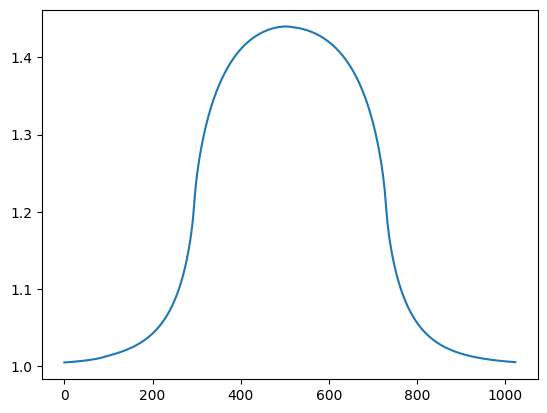

In [43]:
data_ext = np.genfromtxt(r"./src_ext.txt",delimiter=",")
src_loc_x = data_ext.T[0]
src_loc_y = data_ext.T[1]
src_rho = data_ext.T[2]
magnification = data_ext.T[3]
relative_error = data_ext.T[4]
# others be shown in init.cpp Twinkle::write() function
# demo txt file might be different in the following columns
plt.plot(magnification)